# Warm-up: differential expression on the `airway` dataset

This notebook reproduces a standard DESeq2 workflow on the `airway` dataset
(Himes et al. 2014, GSE52778), a canonical RNA-seq reference dataset.

**Dataset:** Human airway smooth muscle cells, 4 treated with dexamethasone
vs 4 untreated controls. 8 samples × ~64k genes (Ensembl IDs).

**Goal:** Run DESeq2 end-to-end, produce volcano + PCA + top-genes heatmap.
This is a foundation for the real DE analysis on GSE50760 (next session).

In [9]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from omics_rag_playground.annotation import map_ensembl_to_symbol

DATA_PATH = "../data/raw/"

 ## Loading Data

 Note that the counts data is in a ‘number of genes’ x ‘number of samples’ format, whereas ‘number of samples’ x ‘number of genes’ is required. To fix this issue, we transpose the counts dataframe.

In [2]:
counts_df = pd.read_csv(DATA_PATH + "airway_scaledcounts.csv", index_col=0)
counts_df = counts_df.T

metadata = pd.read_csv(DATA_PATH + "airway_metadata.csv", index_col=0)

print(counts_df.shape)
print(metadata.info())

(8, 38694)
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, SRR1039508 to SRR1039521
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   dex       8 non-null      object
 1   celltype  8 non-null      object
 2   geo_id    8 non-null      object
dtypes: object(3)
memory usage: 256.0+ bytes
None


### Filtering

In [3]:
samples_to_keep = ~metadata.dex.isna()
print(f"Keeping {samples_to_keep.sum()} out of {counts_df.shape[0]} samples.")

counts_df = counts_df.loc[samples_to_keep]
metadata = metadata.loc[samples_to_keep]


genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
print(f"Keeping {len(genes_to_keep)} out of {counts_df.shape[1]} genes.")

counts_df = counts_df[genes_to_keep]

Keeping 8 out of 8 samples.
Keeping 19271 out of 38694 genes.


## Single Factor Analysis

### DESeq2 fit

In [4]:
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~dex",
    refit_cooks=True,
)

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.39 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 3.79 seconds.

Fitting LFCs...
... done in 2.43 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [5]:
ds = DeseqStats(dds, contrast=["dex", "treated", "control"])
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: dex treated vs control
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ensgene                                                                      
ENSG00000000003   747.189148       -0.350621  0.167748 -2.090170  0.036603   
ENSG00000000419   520.134010        0.206117  0.098666  2.089028  0.036705   
ENSG00000000457   322.663544        0.024617  0.143567  0.171467  0.863857   
ENSG00000000460    87.682256       -0.147089  0.256367 -0.573745  0.566140   
ENSG00000000971  5760.147543        0.459354  0.235307  1.952146  0.050921   
...                      ...             ...       ...       ...       ...   
ENSG00000283091    58.877933       -0.181852  0.256175 -0.709873  0.477783   
ENSG00000283094  1881.014795       -0.343844  0.104155 -3.301264  0.000963   
ENSG00000283100   579.160373       -0.064848  0.125825 -0.515380  0.606287   
ENSG00000283101     7.068460        0.677440  0.723641  0.936155  0.349193   
ENS

... done in 0.75 seconds.



In [6]:
ds.lfc_shrink(coeff="dex[T.treated]")

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: dex[T.treated]
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ensgene                                                                      
ENSG00000000003   747.189148       -0.273767  0.164754 -2.090170  0.036603   
ENSG00000000419   520.134010        0.183884  0.096959  2.089028  0.036705   
ENSG00000000457   322.663544        0.018679  0.133130  0.171467  0.863857   
ENSG00000000460    87.682256       -0.073052  0.211059 -0.573745  0.566140   
ENSG00000000971  5760.147543        0.305483  0.231543  1.952146  0.050921   
...                      ...             ...       ...       ...       ...   
ENSG00000283091    58.877933       -0.091877  0.212567 -0.709873  0.477783   
ENSG00000283094  1881.014795       -0.313417  0.103880 -3.301264  0.000963   
ENSG00000283100   579.160373       -0.051881  0.118938 -0.515380  0.606287   
ENSG00000283101     7.068460        0.075152  0.355072  0.936155  0.349193   
ENSG

... done in 3.22 seconds.



In [7]:
# How many significant genes are there (FDR < 0.05)?
n_sig = (ds.results_df["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig}")

# Top 20 DE genes sorted by padj (most significant at the top)
top_by_padj = ds.results_df.sort_values("padj").head(20)
print(top_by_padj[["baseMean", "log2FoldChange", "padj"]])

# Top 20 most upregulated among significant genes (highest positive values)
sig = ds.results_df[ds.results_df["padj"] < 0.05]
top_up = sig.nlargest(20, "log2FoldChange")[["baseMean", "log2FoldChange", "padj"]]

# Top 20 most downregulated among significant genes
top_down = sig.nsmallest(20, "log2FoldChange")[["baseMean", "log2FoldChange", "padj"]]

Significant DE genes (padj < 0.05): 2200
                     baseMean  log2FoldChange          padj
ensgene                                                    
ENSG00000152583    954.794476        4.343030  4.509272e-71
ENSG00000116584   2277.885406       -1.027747  3.052201e-58
ENSG00000179094    743.267870        2.842992  2.166313e-56
ENSG00000189221   2383.801786        3.315147  6.792820e-52
ENSG00000120129   3440.774824        2.938280  2.474989e-44
ENSG00000148175  13494.047433        1.414390  7.376043e-44
ENSG00000178695   2685.346282       -2.463416  3.771760e-41
ENSG00000134686   2933.671715        1.425316  4.518537e-40
ENSG00000109906    439.553164        5.864337  1.821215e-39
ENSG00000101347  14135.338375        3.808696  6.635716e-38
ENSG00000096060   2630.296201        3.901774  1.235599e-37
ENSG00000166741   7542.374822        2.195490  1.947087e-37
ENSG00000125148   3695.933384        2.174067  1.217675e-36
ENSG00000162614   5646.266220        1.947199  1.350906e-36

In [10]:
results_df = ds.results_df.copy()
symbols = map_ensembl_to_symbol(results_df.index)
results_df["symbol"] = symbols

# Validation: CRISPLD2 should map correctly
print(results_df.loc["ENSG00000103196", ["symbol", "log2FoldChange", "padj"]])

2 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000277033', 2)]
223 input query terms found no hit:	['ENSG00000002079', 'ENSG00000069712', 'ENSG00000112096', 'ENSG00000116957', 'ENSG00000130201', 'ENS


symbol            CRISPLD2
log2FoldChange    2.571553
padj                   0.0
Name: ENSG00000103196, dtype: object


## Visualization

### Volcano plot

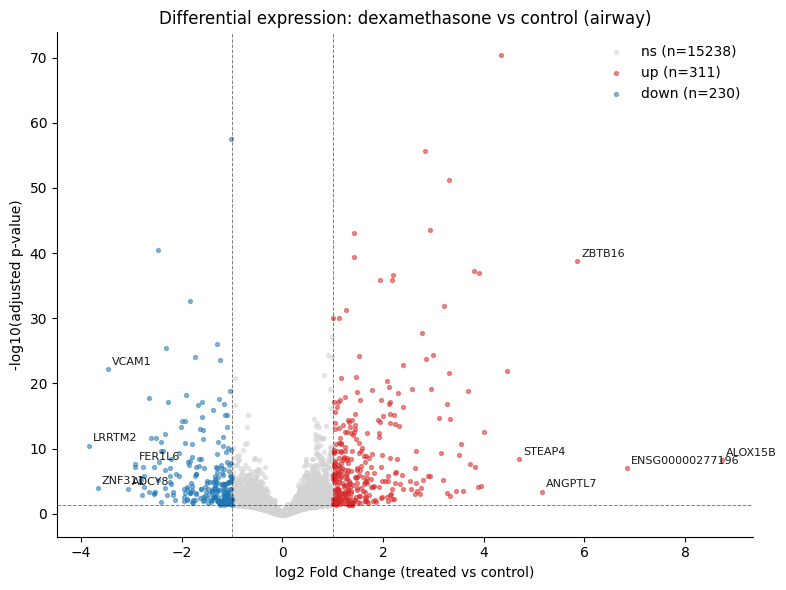

In [10]:
# Standard thresholds in RNA-seq literature
LFC_THRESHOLD = 1.0     # |log2FC| > 1, i.e. fold change > 2x
PADJ_THRESHOLD = 0.05   # FDR < 5%

df = ds.results_df.dropna(subset=["padj"]).copy()
df["neg_log10_padj"] = -np.log10(df["padj"])

# Category for coloring
df["category"] = "ns"  # not significant
df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] > LFC_THRESHOLD), "category"] = "up"
df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] < -LFC_THRESHOLD), "category"] = "down"

colors = {"ns": "lightgray", "up": "#d62728", "down": "#1f77b4"}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, color in colors.items():
    sub = df[df["category"] == cat]
    ax.scatter(sub["log2FoldChange"], sub["neg_log10_padj"],
               s=8, alpha=0.5, c=color, label=f"{cat} (n={len(sub)})")
    
# Top 5 among "up" and "down"
to_annotate = pd.concat([
    results_df[results_df["padj"] < 0.05].nlargest(5, "log2FoldChange"),
    results_df[results_df["padj"] < 0.05].nsmallest(5, "log2FoldChange"),
])

for ensembl_id, row in to_annotate.iterrows():
    label = row["symbol"] if pd.notna(row["symbol"]) else ensembl_id[-15:]
    ax.annotate(label,
                (row["log2FoldChange"], -np.log10(row["padj"])),
                fontsize=8, alpha=0.9,
                xytext=(3, 3), textcoords="offset points")

# Threshold lines
ax.axhline(-np.log10(PADJ_THRESHOLD), ls="--", c="black", lw=0.7, alpha=0.5)
ax.axvline(LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)
ax.axvline(-LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)

ax.set_xlabel("log2 Fold Change (treated vs control)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Differential expression: dexamethasone vs control (airway)")
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Dimensionality Reduction

In [11]:
dds.vst()
vst_counts = dds.layers["vst_counts"]  # numpy array (n_samples, n_genes)

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.04 seconds.



In [12]:
pca = PCA(n_components=2)
coords = pca.fit_transform(vst_counts)

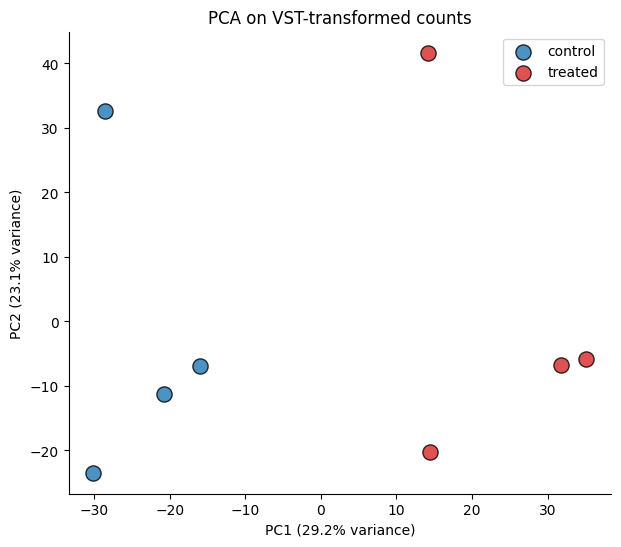

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
for cond, color in [("control", "#1f77b4"), ("treated", "#d62728")]:
    mask = (metadata["dex"] == cond).values
    ax.scatter(coords[mask, 0], coords[mask, 1], 
               s=120, c=color, label=cond, alpha=0.8, edgecolor="k")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA on VST-transformed counts")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

**NOTE:** PC1 (29.2% variance) cleanly separates dexamethasone-treated from control samples, confirming that the treatment is the dominant biological signal. PC2 (23.1%) appears to capture donor-level variability, a strong argument for a multi-factor design (~celltype + dex) in a more rigorous analysis.

## Top DE genes heatmap

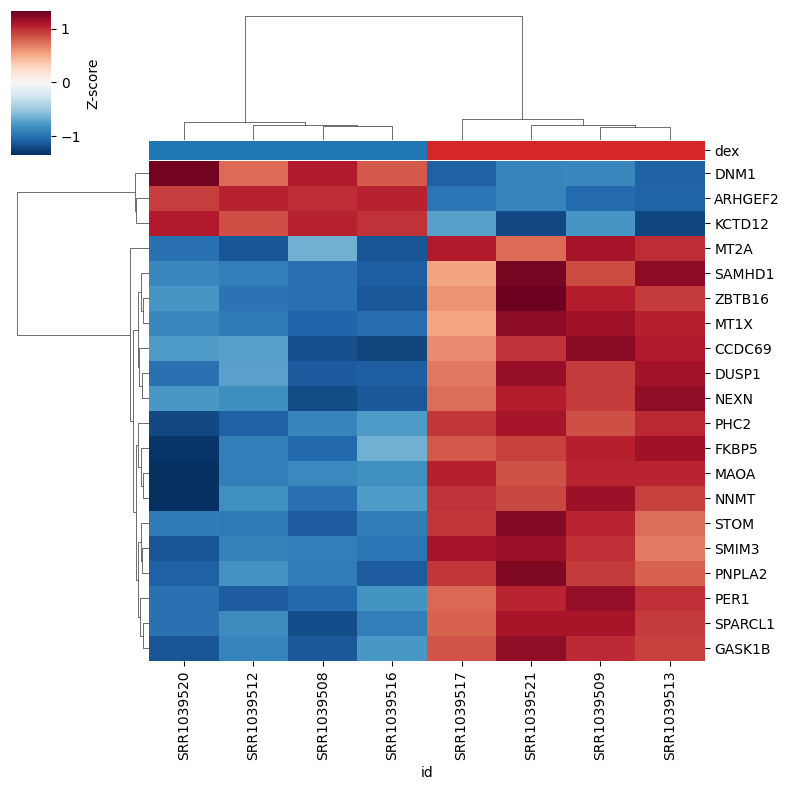

In [14]:
# Top 20 più significativi (padj più basso), tra quelli mappati a un symbol
top20 = (
    results_df[results_df["symbol"].notna()]
    .sort_values("padj")
    .head(20)
)

# Estrai le righe della matrice VST corrispondenti
# vst_counts è (samples, genes), serve indicizzare le colonne
gene_indices = [list(dds.var_names).index(g) for g in top20.index]
heatmap_matrix = vst_counts[:, gene_indices].T  # (20 genes, 8 samples)

# Z-score per riga (per ogni gene, normalizza tra campioni)
heatmap_z = (heatmap_matrix - heatmap_matrix.mean(axis=1, keepdims=True)) / heatmap_matrix.std(axis=1, keepdims=True)

# DataFrame con label leggibili
heatmap_df = pd.DataFrame(
    heatmap_z,
    index=top20["symbol"].values,
    columns=metadata.index,
)

# Color annotation per condizione
col_colors = metadata["dex"].map({"control": "#1f77b4", "treated": "#d62728"})

g = sns.clustermap(
    heatmap_df,
    cmap="RdBu_r",
    center=0,
    col_colors=col_colors,
    figsize=(8, 8),
    cbar_kws={"label": "Z-score"},
    yticklabels=True,
    xticklabels=True,
)

**NOTE:** The top 20 most significant DE genes cleanly cluster the 8 samples into the correct treatment groups (dendrogram on columns matches the dex annotation perfectly). The 17-gene upregulated cluster includes well-known glucocorticoid-responsive genes (FKBP5, PER1, DUSP1, ZBTB16, MT1X/MT2A), confirming both the statistical validity of the pipeline and its biological soundness.